# Analysis and Visualization of Composite Diagnostics

**Author:** Mingshi Yang (mingshi3@illinois.edu)  
**Date:** 2026-06-21  

**Project:**  
*Characteristics of Midlatitude Cyclones under Climate Change in a Global Storm-Resolving Model*

**Description:**  
Created during Revision 1, this notebook generates S7, S8, and S10 by comparison the linearity of effect of SST and CO2 forcings.


In [1]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
from numpy import dtype
from scipy import stats
from datetime import date
import collections
import cartopy.crs as ccrs
import os
from scipy.stats import circmean
import pickle
from scipy.ndimage import uniform_filter
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib import colors
from tqdm import tqdm

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
track_dir = '/data/keeling/a/mingshi3/c/xshield/Midlatitude-Cyclone-in-X-SHiELD/data/tracks'
composites_derived_dir = '/data/keeling/a/mingshi3/c/xshield/Midlatitude-Cyclone-in-X-SHiELD/data/composites'
composites_raw_dir = '/data/keeling/a/mingshi3/c/xshield/composites'

In [4]:
experiments = [ 'PIRE',
                'PIRE_CO2_1270ppmv',
                'PIRE_PLUS_4K',
                'PIRE_PLUS_4K_CO2_1270ppmv']

experiments_display = [ 'CTRL   ',
                '+CO₂   ',
                '+4K    ',
                '+4K+CO₂']

expnames = ['ERA5   '] + experiments_display

colorlist = ['gray','black','C0','C1','C3','C4']

In [5]:
tk = []
idx = []
for exp in experiments:
    tk.append(np.loadtxt(f'{track_dir}/TK2Y-{exp}/All_Tracks.txt'))
    idx.append(np.loadtxt(f'{track_dir}/TK2Y-{exp}/All_Indexes.txt'))

In [6]:
xplot = (np.arange(201)*25-2500) / 1000

In [7]:
# plot figure 3 using 2020-2021 data
data_95_file = f'{composites_derived_dir}/TK2Y-allexp_p95_uv925.npy'
if os.path.isfile(data_95_file):
    data_95 = [d for d in np.load(data_95_file)]
else:
    data = []
    for i, exp in enumerate(experiments):

        print(exp)
        d = tk[i]
        sel0 = np.array((d[:,0]>2020000000)&(d[:,0]<2022000000)&(d[:,1]<65)&(d[:,1]>=30))

        expf = exp.replace("\n","")
        data.append(np.load(f'/glade/work/mingshiy/XSHIELD/data/Composites/TK2Y-{expf}_uv925.npy',mmap_mode='r')[sel0].astype(np.float32))
        data_95 = [np.nanpercentile(d,95,axis=(0)) for d in data]
        np.save(data_95_file,np.array(data_95))

In [8]:
mean_uv = np.load(f'{composites_derived_dir}/TK2Y-allexp_means_uv925_t.npy')
pval_uv = np.load(f'{composites_derived_dir}/TK2Y-allexp-ctrl_pvalue_uv925_t.npy')

In [9]:
mean_uv.shape, pval_uv.shape

((4, 201, 201), (3, 201, 201))

Figure S7

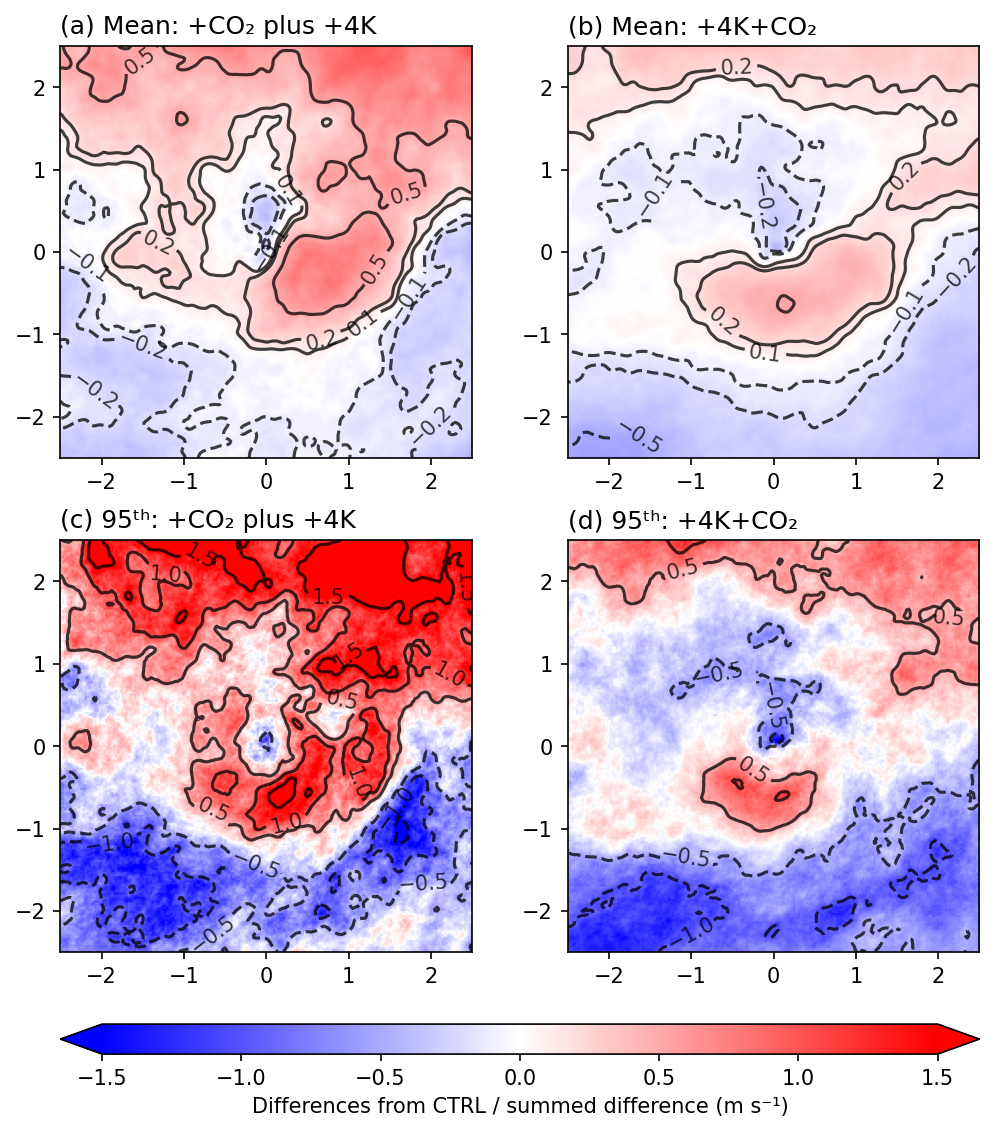

In [10]:
letters = 'abcd'
fig, axes = plt.subplots(2, 2, figsize=(8, 8), dpi=150)

# assumed order: 0=CTRL, 1=+CO2, 2=+4K, 3=+4K+CO2
mean_sumdiff = (mean_uv[1] - mean_uv[0]) + (mean_uv[2] - mean_uv[0])
mean_combined = mean_uv[3] - mean_uv[0]

p95_sumdiff = (data_95[1] - data_95[0]) + (data_95[2] - data_95[0])
p95_combined = data_95[3] - data_95[0]

plot_data = [
    (mean_sumdiff, '(a) Mean: +CO₂ plus +4K'),
    (mean_combined, '(b) Mean: +4K+CO₂'),
    (p95_sumdiff, '(c) 95ᵗʰ: +CO₂ plus +4K'),
    (p95_combined, '(d) 95ᵗʰ: +4K+CO₂'),
]

for i, ax in enumerate(axes.ravel()):
    dat, title = plot_data[i]

    im = ax.imshow(
        dat, cmap='bwr', vmin=-1.5, vmax=1.5,
        extent=[xplot[0], xplot[-1], xplot[0], xplot[-1]]
    )

    ct = ax.contour(
        xplot, xplot[::-1],
        uniform_filter(dat, 5),
        colors='black',
        levels=[-1.5,-1,-0.5,-0.2,-0.1,0.1,0.2,0.5,1,1.5] if i < 2 else [-1.5,-1,-0.5,0.5,1,1.5],
        alpha=0.75
    )
    ax.clabel(ct)
    ax.set_title(title, loc='left')

# one shared colorbar
bbox0 = axes[1, 0].get_position()
bbox1 = axes[1, 1].get_position()
cbar_ax = fig.add_axes([bbox0.x0, 0.04, bbox1.x1 - bbox0.x0, 0.025])
cb = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='both')
cb.set_label('Differences from CTRL / summed difference (m s⁻¹)')

plt.show()

In [11]:
mean_pr = np.load(f'{composites_derived_dir}/TK2Y-allexp_means_PRATEsfc_t.npy')
pval_pr = np.load(f'{composites_derived_dir}/TK2Y-allexp-ctrl_pvalue_PRATEsfc_t.npy')
mean_sta = np.load(f'{composites_derived_dir}/TK2Y-allexp_means_stability-thetae-200925_t.npy')
pval_sta = np.load(f'{composites_derived_dir}/TK2Y-allexp-ctrl_pvalue_stability-thetae-200925_t.npy')

Figure S8

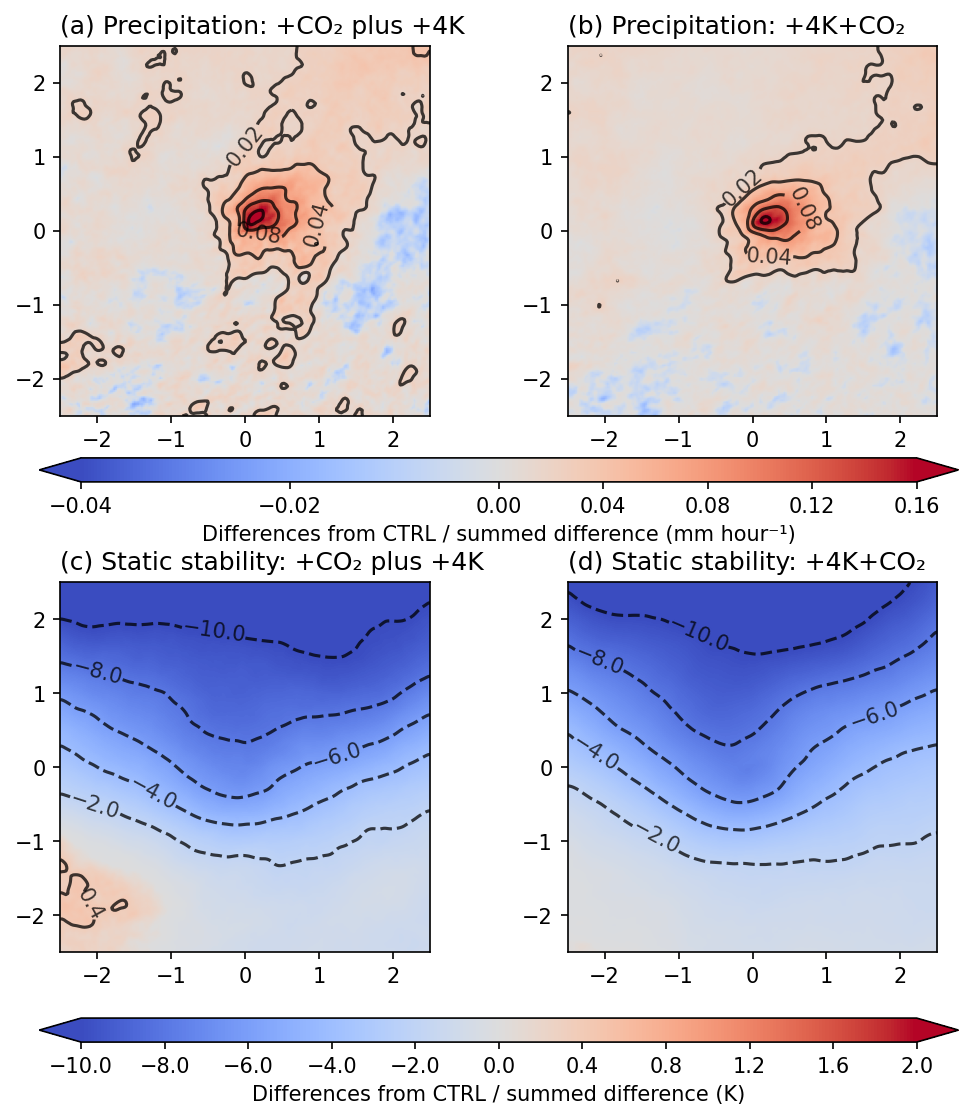

In [12]:
# ============================================================
# Combined precipitation + static stability linearity figure
# 2 rows x 2 columns
# Same style as wind linearity plot
# ============================================================

letters = 'abcd'
fig, axes = plt.subplots(2, 2, figsize=(8, 8), dpi=150)

# assumed order: 0=CTRL, 1=+CO2, 2=+4K, 3=+4K+CO2
pr_sumdiff = (mean_pr[1] - mean_pr[0]) + (mean_pr[2] - mean_pr[0])
pr_combined = mean_pr[3] - mean_pr[0]

sta_sumdiff = (mean_sta[1] - mean_sta[0]) + (mean_sta[2] - mean_sta[0])
sta_combined = mean_sta[3] - mean_sta[0]

plot_data = [
    (pr_sumdiff * 3600, '(a) Precipitation: +CO₂ plus +4K', 'pr'),
    (pr_combined * 3600, '(b) Precipitation: +4K+CO₂', 'pr'),
    (sta_sumdiff, '(c) Static stability: +CO₂ plus +4K', 'sta'),
    (sta_combined, '(d) Static stability: +4K+CO₂', 'sta'),
]

pr_norm = colors.TwoSlopeNorm(vmin=-0.04, vcenter=0, vmax=0.16)
sta_norm = colors.TwoSlopeNorm(vmin=-10, vcenter=0, vmax=2)

for i, ax in enumerate(axes.ravel()):

    dat, title, vtype = plot_data[i]

    if vtype == 'pr':
        im_pr = ax.imshow(
            dat, cmap='coolwarm', norm=pr_norm,
            extent=[xplot[0], xplot[-1], xplot[0], xplot[-1]]
        )

        ct = ax.contour(
            xplot, xplot[::-1],
            uniform_filter(dat, 5),
            colors='black',
            levels=[-0.04, -0.02, 0.02, 0.04, 0.08, 0.12, 0.16],
            alpha=0.75
        )

    else:
        im_sta = ax.imshow(
            dat, cmap='coolwarm', norm=sta_norm,
            extent=[xplot[0], xplot[-1], xplot[0], xplot[-1]]
        )

        ct = ax.contour(
            xplot, xplot[::-1],
            uniform_filter(dat, 5),
            colors='black',
            levels=[-10, -8, -6, -4, -2, 0.4, 0.8, 1.2, 1.6, 2],
            alpha=0.75
        )

    ax.clabel(ct)
    ax.set_title(title, loc='left')

# colorbar for precipitation row
bbox0 = axes[0, 0].get_position()
bbox1 = axes[0, 1].get_position()
cbar_ax = fig.add_axes([bbox0.x0, bbox0.y0 - 0.02, bbox1.x1 - bbox0.x0, 0.02])
cb = fig.colorbar(im_pr, cax=cbar_ax, orientation='horizontal', extend='both')
cb.set_label('Differences from CTRL / summed difference (mm hour⁻¹)')
cbar_ax.set_xticks([-0.04, -0.02, 0, 0.04, 0.08, 0.12, 0.16])

# colorbar for static stability row
bbox0 = axes[1, 0].get_position()
bbox1 = axes[1, 1].get_position()
cbar_ax = fig.add_axes([bbox0.x0, 0.05, bbox1.x1 - bbox0.x0, 0.02])
cb = fig.colorbar(im_sta, cax=cbar_ax, orientation='horizontal', extend='both')
cb.set_label('Differences from CTRL / summed difference (K)')
cbar_ax.set_xticks([-10, -8, -6, -4, -2, 0, 0.4, 0.8, 1.2, 1.6, 2])
fig.subplots_adjust(hspace=0.45)
plt.show()

In [13]:
levels = [1000,925,850,700,500,200,50]

In [14]:
def dmatrix(r,res):
    x = np.arange(-r,r+1e-10,res)
    y = x.copy()
    xx,yy = np.meshgrid(x,y)
    dm = np.ones_like(xx)
    dm[(xx**2+yy**2)>r**2] = np.nan
    return dm
d2500 = dmatrix(2500,25)
d2500.shape

(201, 201)

In [15]:
# obtain the cross section
def get_cross_data(var_name,idx,iaxis):
    cross = np.zeros((4,len(levels),201))
    anom = np.zeros((4,len(levels),201))
    p = np.zeros((3,len(levels),201))
    for i, lvl in enumerate(levels):
        p_var = np.load(f'{composites_derived_dir}/TK2Y-allexp-ctrl_pvalue_{var_name}{lvl}_t.npy')
        p_var = np.take(p_var,idx,iaxis)
        mean_var = np.load(f'{composites_derived_dir}/TK2Y-allexp_means_{var_name}{lvl}_t.npy')
        anom_var = np.take(mean_var - np.nanmean(mean_var*d2500[None,:,:],axis=(-2,-1),keepdims=True),idx,iaxis)
        mean_var = np.take(mean_var,idx,iaxis)
        cross[:,i] = mean_var
        anom[:,i] = anom_var
        p[:,i] = p_var
    return cross, anom, p

Figure S10

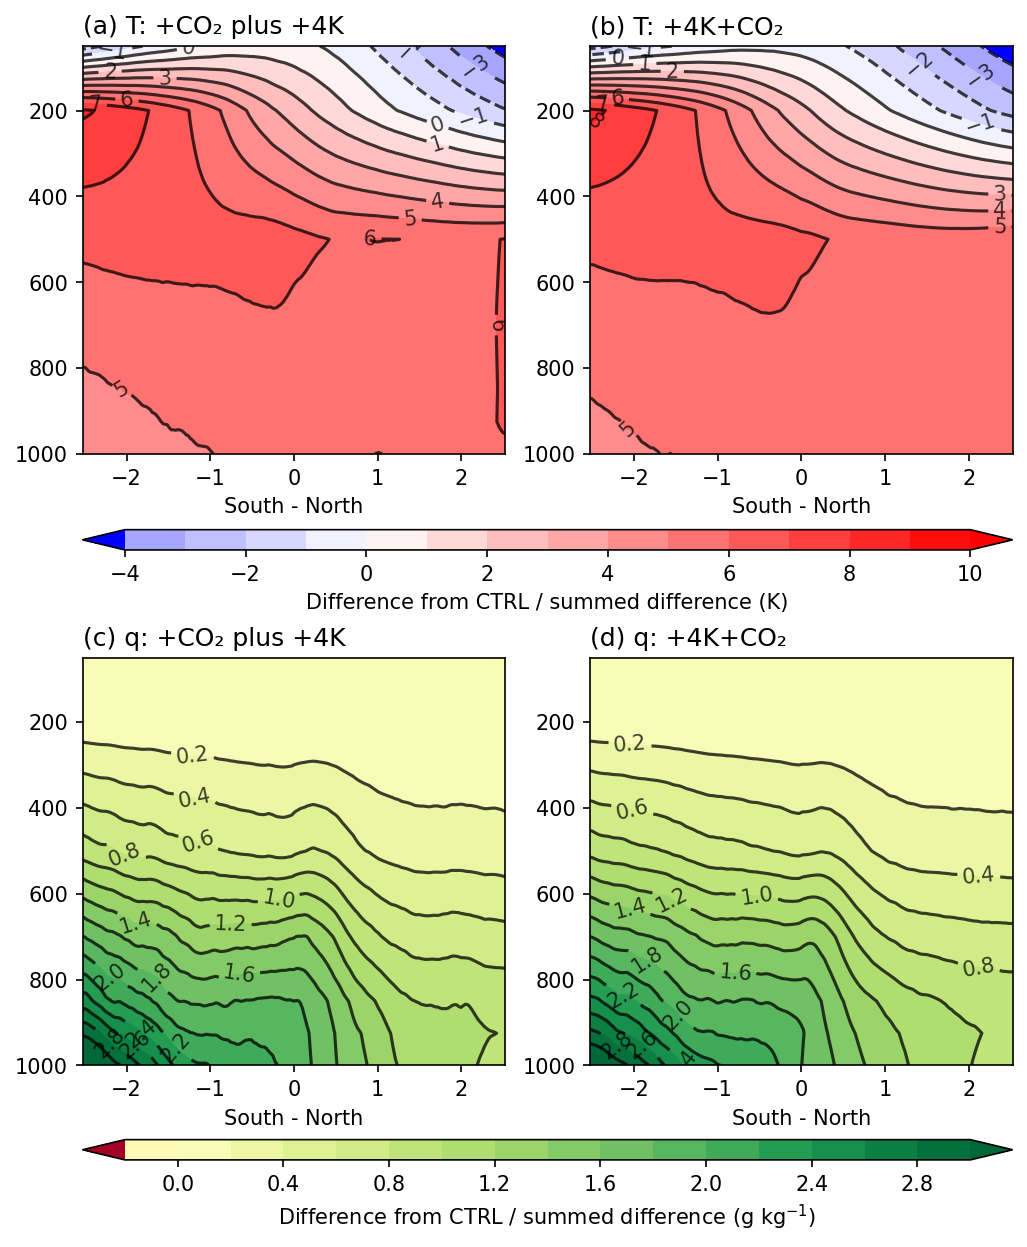

In [16]:
letters = 'abcd'
fig, axes = plt.subplots(2, 2, figsize=(8, 9), dpi=150)

xsec = np.linspace(-101, 101, 201) * 25 / 1000

# =========================
# Temperature
# =========================
cross_t, anom_t, p_t = get_cross_data('t', 100, -1)
cross_t = cross_t[:, :, ::-1]

t_sumdiff = (cross_t[1] - cross_t[0]) + (cross_t[2] - cross_t[0])
t_combined = cross_t[3] - cross_t[0]

plot_t = [
    (t_sumdiff, '(a) T: +CO₂ plus +4K'),
    (t_combined, '(b) T: +4K+CO₂')
]

t_levels = np.linspace(-4, 10, 15)

for i, (dat, title) in enumerate(plot_t):

    cf = axes[0, i].contourf(
        xsec, levels, dat,
        levels=t_levels,
        cmap='bwr',
        extend='both',
        norm=colors.CenteredNorm()
    )

    c = axes[0, i].contour(
        xsec, levels, dat,
        levels=t_levels,
        colors='black',
        alpha=0.75
    )

    axes[0, i].clabel(c)
    axes[0, i].invert_yaxis()
    axes[0, i].set_title(title, loc='left')
    axes[0, i].set_xlabel('South - North')

# =========================
# Specific humidity
# =========================
cross_q, anom_q, p_q = get_cross_data('q', 100, -1)
cross_q = cross_q[:, :, ::-1]

q_sumdiff = (cross_q[1] - cross_q[0]) + (cross_q[2] - cross_q[0])
q_combined = cross_q[3] - cross_q[0]

plot_q = [
    (q_sumdiff * 1000, '(c) q: +CO₂ plus +4K'),
    (q_combined * 1000, '(d) q: +4K+CO₂')
]

q_levels = np.linspace(-0.2, 3, 17)

for i, (dat, title) in enumerate(plot_q):

    cfq = axes[1, i].contourf(
        xsec, levels, dat,
        levels=q_levels,
        cmap='RdYlGn',
        extend='both',
        norm=colors.CenteredNorm()
    )

    c = axes[1, i].contour(
        xsec, levels, dat,
        levels=q_levels,
        colors='black',
        alpha=0.75
    )

    axes[1, i].clabel(c)
    axes[1, i].invert_yaxis()
    axes[1, i].set_title(title, loc='left')
    axes[1, i].set_xlabel('South - North')

# =========================
# colorbars
# =========================
bbox0 = axes[0, 0].get_position()
bbox1 = axes[0, 1].get_position()
cbar_ax = fig.add_axes([bbox0.x0, bbox0.y0 - 0.03, bbox1.x1 - bbox0.x0, 0.015])
cb = fig.colorbar(cf, cax=cbar_ax, orientation='horizontal', extend='both')
cb.set_label('Difference from CTRL / summed difference (K)')

bbox0 = axes[1, 0].get_position()
bbox1 = axes[1, 1].get_position()
cbar_ax = fig.add_axes([bbox0.x0, bbox0.y0 - 0.07, bbox1.x1 - bbox0.x0, 0.015])
cb = fig.colorbar(cfq, cax=cbar_ax, orientation='horizontal', extend='both')
cb.set_label('Difference from CTRL / summed difference (g kg$^{-1}$)')

plt.subplots_adjust(hspace=0.5)
#plt.show()